In [97]:
!pip install optuna

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import KFold

import optuna

In [3]:
def mean_wrinkler_score(y_true, y_pred_lo, y_pred_hi, alpha=0.2):
  scores = np.full(len(y_true), y_pred_hi - y_pred_lo)
  mask_lo = y_true < y_pred_lo
  scores[mask_lo] += (y_pred_lo[mask_lo] - y_true[mask_lo]) * (2/alpha)
  mask_hi = y_true > y_pred_hi
  scores[mask_hi] += (y_true[mask_hi] - y_pred_hi[mask_hi]) * (2/alpha)

  return np.mean(scores)

In [4]:
honey = pd.read_csv('honey.csv', sep=";")
weather = pd.read_csv('df_weekly_2019_2025.csv')
beehives = pd.read_csv('ule.csv', sep=";")

In [5]:
honey.head()

,year,week,honey,harvest
0,2019,30,66.0,1
1,2019,32,55.0,1
2,2019,33,134.0,2
3,2019,34,72.0,1
4,2019,35,59.0,1


In [6]:
beehives.head()

,year,beehive
0,2019,92
1,2020,86
2,2021,98
3,2022,100
4,2023,87


In [7]:
weather.head()

,year,week,temp,wspd,prcp,pres
0,2019,18,8.644572,2.952617,0.247276,940.72546
1,2019,19,8.801729,2.939627,0.163314,946.07404
2,2019,20,10.284056,2.588411,0.200703,949.08860
3,2019,21,13.292661,2.689059,0.371334,943.73720
4,2019,22,14.097325,2.743598,0.164248,950.88153


In [8]:
df = pd.merge(honey, weather, on=["year", "week"], how="inner")

In [9]:
df = pd.merge(df, beehives, on="year", how="inner")

In [10]:
weather_filtered = weather[(weather['week'] >= 18) & (weather['week'] <= 30)]

weather_filtered['feature_week'] = weather_filtered['week'].astype(str) + '_'
weather_pivot = weather_filtered.pivot_table(
    index='year',
    columns='feature_week',
    values=['temp', 'wspd', 'prcp', 'pres']
)

weather_pivot.columns = [f'{col[0]}_{col[1].replace("_", "")}' for col in weather_pivot.columns]

df = pd.merge(df, weather_pivot, on='year', how='left')
df.head()

,year,week,honey,harvest,temp,wspd,prcp,pres,beehive,prcp_18,...,wspd_21,wspd_22,wspd_23,wspd_24,wspd_25,wspd_26,wspd_27,wspd_28,wspd_29,wspd_30
0,2019,30,66.0,1,18.468962,2.068542,0.125877,949.43176,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
1,2019,32,55.0,1,19.387705,1.972191,0.171244,948.63810,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
2,2019,33,134.0,2,16.821316,1.924085,0.108202,949.98334,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
3,2019,34,72.0,1,18.534908,1.906017,0.032221,957.32385,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
4,2019,35,59.0,1,20.576923,1.698392,0.071077,954.63135,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542


In [11]:
df.columns

Index(['year', 'week', 'honey', 'harvest', 'temp', 'wspd', 'prcp', 'pres',
       'beehive', 'prcp_18', 'prcp_19', 'prcp_20', 'prcp_21', 'prcp_22',
       'prcp_23', 'prcp_24', 'prcp_25', 'prcp_26', 'prcp_27', 'prcp_28',
       'prcp_29', 'prcp_30', 'pres_18', 'pres_19', 'pres_20', 'pres_21',
       'pres_22', 'pres_23', 'pres_24', 'pres_25', 'pres_26', 'pres_27',
       'pres_28', 'pres_29', 'pres_30', 'temp_18', 'temp_19', 'temp_20',
       'temp_21', 'temp_22', 'temp_23', 'temp_24', 'temp_25', 'temp_26',
       'temp_27', 'temp_28', 'temp_29', 'temp_30', 'wspd_18', 'wspd_19',
       'wspd_20', 'wspd_21', 'wspd_22', 'wspd_23', 'wspd_24', 'wspd_25',
       'wspd_26', 'wspd_27', 'wspd_28', 'wspd_29', 'wspd_30'],
      dtype='str')

In [12]:
df.head()

,year,week,honey,harvest,temp,wspd,prcp,pres,beehive,prcp_18,...,wspd_21,wspd_22,wspd_23,wspd_24,wspd_25,wspd_26,wspd_27,wspd_28,wspd_29,wspd_30
0,2019,30,66.0,1,18.468962,2.068542,0.125877,949.43176,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
1,2019,32,55.0,1,19.387705,1.972191,0.171244,948.63810,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
2,2019,33,134.0,2,16.821316,1.924085,0.108202,949.98334,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
3,2019,34,72.0,1,18.534908,1.906017,0.032221,957.32385,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
4,2019,35,59.0,1,20.576923,1.698392,0.071077,954.63135,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542


In [13]:
train = df[df["year"] <= 2023]
test = df[df["year"] >= 2024]

In [110]:
# features = ["temp", "wspd", "prcp", "pres", "beehive", "harvest"]

In [15]:
features = [col for col in df.columns if col != 'honey']
print(features)

['year', 'week', 'harvest', 'temp', 'wspd', 'prcp', 'pres', 'beehive', 'prcp_18', 'prcp_19', 'prcp_20', 'prcp_21', 'prcp_22', 'prcp_23', 'prcp_24', 'prcp_25', 'prcp_26', 'prcp_27', 'prcp_28', 'prcp_29', 'prcp_30', 'pres_18', 'pres_19', 'pres_20', 'pres_21', 'pres_22', 'pres_23', 'pres_24', 'pres_25', 'pres_26', 'pres_27', 'pres_28', 'pres_29', 'pres_30', 'temp_18', 'temp_19', 'temp_20', 'temp_21', 'temp_22', 'temp_23', 'temp_24', 'temp_25', 'temp_26', 'temp_27', 'temp_28', 'temp_29', 'temp_30', 'wspd_18', 'wspd_19', 'wspd_20', 'wspd_21', 'wspd_22', 'wspd_23', 'wspd_24', 'wspd_25', 'wspd_26', 'wspd_27', 'wspd_28', 'wspd_29', 'wspd_30']


In [16]:
X_train = train[features]
y_train = train["honey"]

X_test = test[features]
y_test = test["honey"]

In [17]:
# najlepszy
model = Ridge(
    alpha=10.0
)

In [114]:
# model = RandomForestRegressor(
#     n_estimators=300,
#     random_state=42
# )

In [18]:
model.fit(X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",10.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [19]:
y_pred = model.predict(X_test)

In [20]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 27.3579902239342
RMSE: 35.536049869677726


In [21]:
results = test.copy()
results["predicted_honey"] = y_pred

print(results[["year", "week", "honey", "predicted_honey"]])

    year  week  honey  predicted_honey
33  2024    27  126.7       113.548847
34  2024    28   45.5        74.433521
35  2024    30  134.4       120.865821
36  2024    31   72.8       128.709522
37  2024    32  105.0       129.730574
38  2024    33   65.8        98.796326
39  2024    34  100.1       125.308884
40  2024    35   53.9       136.364518
41  2024    37  148.4       152.117220
42  2025    28  126.7       120.643196
43  2025    31  191.1       189.740373
44  2025    33   42.0       101.012220
45  2025    35  109.9       132.528040
46  2025    36  217.0       203.690725


In [22]:
real_test_honey = sum(test["honey"])
predicted_honey_sum = sum(results["predicted_honey"])
print(predicted_honey_sum - real_test_honey)

288.1897883256263


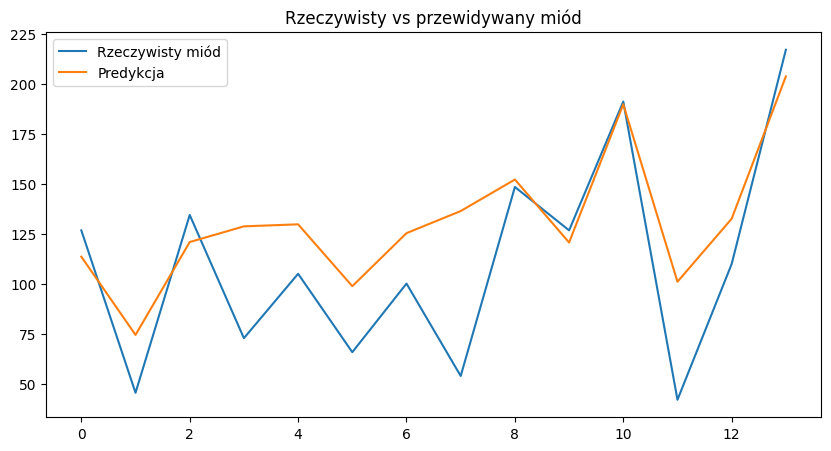

In [23]:
plt.figure(figsize=(10,5))
plt.plot(results["honey"].values, label="Rzeczywisty miód")
plt.plot(results["predicted_honey"].values, label="Predykcja")
plt.legend()
plt.title("Rzeczywisty vs przewidywany miód")
plt.show()

In [121]:
# def objective(trial):
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
#         'max_depth': trial.suggest_int('max_depth', 2, 10),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'gamma': trial.suggest_float('gamma', 0.0, 0.5),
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
#         'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
#         'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
#         'objective': 'reg:squarederror',
#         'random_state': 42
#     }

#     kf = KFold(n_splits=10, shuffle=True, random_state=42)
#     mae_scores = []

#     for train_index, val_index in kf.split(X_train, y_train):
#         X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
#         y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

#         model = XGBRegressor(**params)
#         model.fit(X_train_fold, y_train_fold)
#         preds = model.predict(X_val_fold)
#         mae = mean_absolute_error(y_val_fold, preds)
#         mae_scores.append(mae)

#     return np.mean(mae_scores)

# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=400)

# print("Number of finished trials: ", len(study.trials))
# print("Best trial:")
# trial = study.best_trial

# print("  Value: {}".format(trial.value))
# print("  Params: ")
# for key, value in trial.params.items():
#     print("    {}: {}".format(key, value))

In [26]:
model = XGBRegressor(
    n_estimators = 535,
    max_depth = 2,
    learning_rate = 0.2921792932332326,
    subsample = 0.9155337675817755,
    colsample_bytree = 0.8845054280373575,
    gamma = 0.3765311627058617,
    min_child_weight = 4,
    reg_alpha = 0.0017374350645646623,
    reg_lambda = 1.7116226997682449
)

model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8845054280373575
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import

In [123]:
# model = XGBRegressor(
#     n_estimators = 246,
#     max_depth = 2,
#     learning_rate = 0.011133650506553542,
#     subsample = 0.9473110238449685,
#     colsample_bytree = 0.9736095478543997,
#     gamma = 0.08740556580122627,
#     min_child_weight = 6,
#     reg_alpha = 0.0016821754165382188,
#     reg_lambda = 0.0016821754165382188
# )

# model.fit(X_train, y_train)


In [27]:
y_pred = model.predict(X_test)

In [28]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 34.79789030892508
RMSE: 44.0521398868262


In [29]:
results = test.copy()
results["predicted_honey"] = y_pred

print(results[["year", "week", "honey", "predicted_honey"]].head())

    year  week  honey  predicted_honey
33  2024    27  126.7        75.373810
34  2024    28   45.5       134.298447
35  2024    30  134.4        72.119217
36  2024    31   72.8        57.785400
37  2024    32  105.0       171.363190


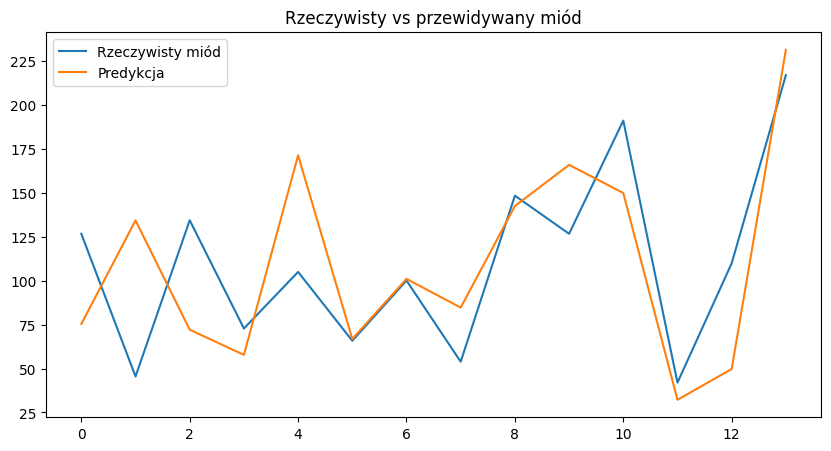

In [30]:
plt.figure(figsize=(10,5))
plt.plot(results["honey"].values, label="Rzeczywisty miód")
plt.plot(results["predicted_honey"].values, label="Predykcja")
plt.legend()
plt.title("Rzeczywisty vs przewidywany miód")
plt.show()

In [31]:
real_test_honey_2024 = test.loc[test["year"] == 2024, "honey"].sum()
predicted_honey_sum_2024 = results.loc[results["year"] == 2024, "predicted_honey"].sum()

print(predicted_honey_sum_2024 - real_test_honey_2024)

53.39816894531248


In [32]:
real_test_honey_2025 = test.loc[test["year"] == 2025, "honey"].sum()
predicted_honey_sum_2025 = results.loc[results["year"] == 2025, "predicted_honey"].sum()

print(predicted_honey_sum_2025 - real_test_honey_2025)

-57.482714843750045


In [33]:
real_test_honey_2024 = test.loc[test["year"] == 2024, "honey"].sum()
real_test_honey_2025 = test.loc[test["year"] == 2025, "honey"].sum()

In [34]:
prc_2024 = (predicted_honey_sum_2024 - real_test_honey_2024) / real_test_honey_2024 * 100
prc_2025 = (predicted_honey_sum_2025 - real_test_honey_2025) / real_test_honey_2025 * 100

In [35]:
print(f"2024: {prc_2024}, 2025: {prc_2025}")

2024: 6.262980171864001, 2025: -8.370862799439353


In [36]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

mae_scores = []
rmse_scores = []

for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):

    X_train_fold = X_train.iloc[train_index]
    X_val_fold = X_train.iloc[val_index]
    y_train_fold = y_train.iloc[train_index]
    y_val_fold = y_train.iloc[val_index]

    cv_model = XGBRegressor(
        n_estimators=535,
        max_depth=2,
        learning_rate=0.2921792932332326,
        subsample=0.9155337675817755,
        colsample_bytree=0.8845054280373575,
        gamma=0.3765311627058617,
        min_child_weight=4,
        reg_alpha=0.0017374350645646623,
        reg_lambda=1.7116226997682449
    )

    cv_model.fit(X_train_fold, y_train_fold)

    y_pred_fold = cv_model.predict(X_val_fold)

    fold_mae = mean_absolute_error(y_val_fold, y_pred_fold)
    fold_rmse = np.sqrt(mean_squared_error(y_val_fold, y_pred_fold))

    mae_scores.append(fold_mae)
    rmse_scores.append(fold_rmse)

    print(f"Fold {fold + 1} - MAE: {fold_mae:.2f}, RMSE: {fold_rmse:.2f}")

print("\nAverage MAE:", np.mean(mae_scores))
print("Average RMSE:", np.mean(rmse_scores))

Fold 1 - MAE: 55.28, RMSE: 74.91
Fold 2 - MAE: 48.39, RMSE: 66.55
Fold 3 - MAE: 35.10, RMSE: 39.14
Fold 4 - MAE: 69.08, RMSE: 80.21
Fold 5 - MAE: 36.54, RMSE: 47.13
Fold 6 - MAE: 87.65, RMSE: 89.26
Fold 7 - MAE: 49.81, RMSE: 52.77
Fold 8 - MAE: 75.81, RMSE: 94.36
Fold 9 - MAE: 40.98, RMSE: 63.72
Fold 10 - MAE: 102.51, RMSE: 123.20

Average MAE: 60.113602587382005
Average RMSE: 73.12479034017699


In [134]:
corr = df.corr()
honey_corr = corr["honey"].sort_values(ascending=False)

honey_corr

,honey
honey,1.000000
harvest,0.526461
prcp,0.409763
wspd,0.380275
prcp_26,0.311182
...,...
temp_23,-0.246829
temp_21,-0.252554
wspd_27,-0.268982
temp_22,-0.290444


In [135]:
train = df[df["year"] <= 2022]
test = df[df["year"] >= 2023]

In [136]:
X_train = train[features]
y_train = train["honey"]

X_test = test[features]
y_test = test["honey"]

In [137]:
model = XGBRegressor(
    n_estimators = 535,
    max_depth = 2,
    learning_rate = 0.2921792932332326,
    subsample = 0.9155337675817755,
    colsample_bytree = 0.8845054280373575,
    gamma = 0.3765311627058617,
    min_child_weight = 4,
    reg_alpha = 0.0017374350645646623,
    reg_lambda = 1.7116226997682449
)

model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8845054280373575, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0.3765311627058617, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.2921792932332326,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=2, max_leaves=None,
             min_child_weight=4, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=535, n_jobs=None,
             num_parallel_tree=None, ...)

In [138]:
# model = XGBRegressor(
#     n_estimators = 246,
#     max_depth = 2,
#     learning_rate = 0.011133650506553542,
#     subsample = 0.9473110238449685,
#     colsample_bytree = 0.9736095478543997,
#     gamma = 0.08740556580122627,
#     min_child_weight = 6,
#     reg_alpha = 0.0016821754165382188,
#     reg_lambda = 0.0016821754165382188
# )

# model.fit(X_train, y_train)

In [139]:
y_pred = model.predict(X_test)

In [140]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 36.66369743347168
RMSE: 44.94112753748846


In [141]:
results = test.copy()
results["predicted_honey"] = y_pred

print(results[["year", "week", "honey", "predicted_honey"]].head())

    year  week  honey  predicted_honey
29  2023    26  131.6       223.313904
30  2023    27  159.6       157.064514
31  2023    33   81.9        50.030785
32  2023    35  171.5       234.683578
33  2024    27  126.7       100.978043


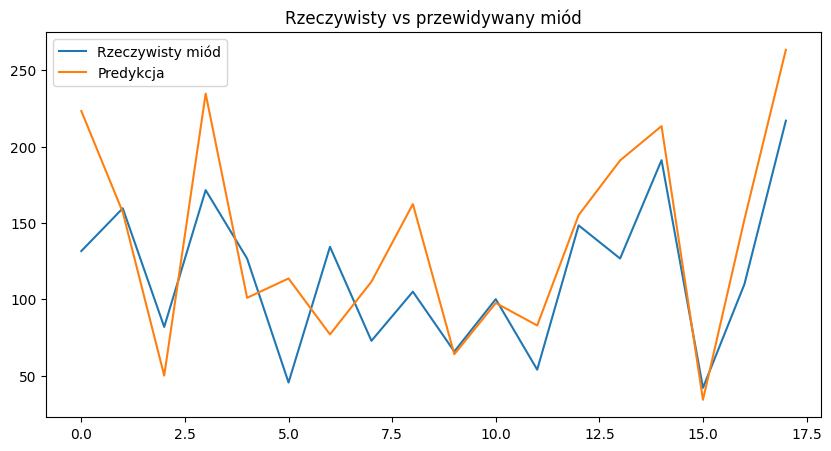

In [142]:
plt.figure(figsize=(10,5))
plt.plot(results["honey"].values, label="Rzeczywisty miód")
plt.plot(results["predicted_honey"].values, label="Predykcja")
plt.legend()
plt.title("Rzeczywisty vs przewidywany miód")
plt.show()

In [143]:
real_test_honey_2024 = test.loc[test["year"] == 2024, "honey"].sum()
predicted_honey_sum_2024 = results.loc[results["year"] == 2024, "predicted_honey"].sum()

real_test_honey_2025 = test.loc[test["year"] == 2025, "honey"].sum()
predicted_honey_sum_2025 = results.loc[results["year"] == 2025, "predicted_honey"].sum()

real_test_honey_2023 = test.loc[test["year"] == 2023, "honey"].sum()
predicted_honey_sum_2023 = results.loc[results["year"] == 2023, "predicted_honey"].sum()

real_test_honey_2024 = test.loc[test["year"] == 2024, "honey"].sum()
real_test_honey_2025 = test.loc[test["year"] == 2025, "honey"].sum()
real_test_honey_2023 = test.loc[test["year"] == 2023, "honey"].sum()

prc_2024 = (predicted_honey_sum_2024 - real_test_honey_2024) / real_test_honey_2024 * 100
prc_2025 = (predicted_honey_sum_2025 - real_test_honey_2025) / real_test_honey_2025 * 100
prc_2023 = (predicted_honey_sum_2023 - real_test_honey_2023) / real_test_honey_2023 * 100

print(f"2023: {prc_2023}, 2024: {prc_2024}, 2025: {prc_2025}")

2023: 22.12500430361733, 2024: 13.20109393097217, 2025: 24.413193235651477


In [144]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

mae_scores = []
rmse_scores = []

for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):

    X_train_fold = X_train.iloc[train_index]
    X_val_fold = X_train.iloc[val_index]
    y_train_fold = y_train.iloc[train_index]
    y_val_fold = y_train.iloc[val_index]

    cv_model = XGBRegressor(
      n_estimators = 535,
      max_depth = 2,
      learning_rate = 0.2921792932332326,
      subsample = 0.9155337675817755,
      colsample_bytree = 0.8845054280373575,
      gamma = 0.3765311627058617,
      min_child_weight = 4,
      reg_alpha = 0.0017374350645646623,
      reg_lambda = 1.7116226997682449
    )

    cv_model.fit(X_train_fold, y_train_fold)

    y_pred_fold = cv_model.predict(X_val_fold)

    fold_mae = mean_absolute_error(y_val_fold, y_pred_fold)
    fold_rmse = np.sqrt(mean_squared_error(y_val_fold, y_pred_fold))

    mae_scores.append(fold_mae)
    rmse_scores.append(fold_rmse)

    print(f"Fold {fold + 1} - MAE: {fold_mae:.2f}, RMSE: {fold_rmse:.2f}")

print("\nAverage MAE:", np.mean(mae_scores))
print("Average RMSE:", np.mean(rmse_scores))

Fold 1 - MAE: 86.94, RMSE: 89.77
Fold 2 - MAE: 24.75, RMSE: 38.80
Fold 3 - MAE: 93.14, RMSE: 125.83
Fold 4 - MAE: 110.68, RMSE: 126.30
Fold 5 - MAE: 60.94, RMSE: 85.69
Fold 6 - MAE: 29.17, RMSE: 36.41
Fold 7 - MAE: 19.16, RMSE: 29.44
Fold 8 - MAE: 104.38, RMSE: 105.39
Fold 9 - MAE: 92.09, RMSE: 103.98
Fold 10 - MAE: 157.97, RMSE: 169.30

Average MAE: 77.92267767588297
Average RMSE: 91.09039152454253


In [37]:
import pandas as pd
import numpy as np

from sklearn.model_selection import LeaveOneGroupOut, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, ElasticNet, HuberRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# cechy i target
features = [col for col in df.columns if col not in ["honey"]]

X = df[features]
y = df["honey"]

# walidacja po latach
groups = df["year"]
cv = LeaveOneGroupOut()

models = {
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10.0))
    ]),

    "ElasticNet": Pipeline([ #polaczenie ridge i lasso 
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000))
    ]),

    "Huber": Pipeline([ # Huber gdy jsst duzo wartosci odstajacych 
        ("scaler", StandardScaler()),
        ("model", HuberRegressor(max_iter=1000))
    ]),

    "SVR": Pipeline([ #proba zanlezienia gladkiej nieliniowej funkcji, ktora przewiduje arget 
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=10, epsilon=10))
    ]),

    "RandomForest": RandomForestRegressor(
        n_estimators=500,
        max_depth=3,
        min_samples_leaf=3,
        random_state=42
    ),

    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=500,
        max_depth=3,
        min_samples_leaf=3,
        random_state=42
    ),

    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.03,
        max_depth=2,
        random_state=42
    )
}

results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv.split(X, y, groups),
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error"
        }
    )

    results.append({
        "model": name,
        "MAE": -scores["test_mae"].mean(),
        "RMSE": -scores["test_rmse"].mean()
    })

results_df = pd.DataFrame(results).sort_values("MAE")
results_df

,model,MAE,RMSE
1,ElasticNet,43.895134,54.680804
0,Ridge,44.140111,54.722240
5,ExtraTrees,46.361098,58.092439
2,Huber,48.801672,61.152799
4,RandomForest,49.359203,62.603311
6,GradientBoosting,53.048154,66.991340
3,SVR,58.965826,75.255993


In [38]:
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score
cv = LeaveOneGroupOut()

def evaluate_model(model, X, y, groups):
    scores = cross_val_score(model, X, y,cv=cv.split(X, y, groups), scoring="neg_mean_absolute_error")
    
    return -scores.mean()

In [41]:


def objective_ridge(trial):

    alpha = trial.suggest_float("alpha", 0.001, 1000.0 , log = True )


    model = Pipeline([
        ("scaler" ,StandardScaler()),
        ("model",Ridge(alpha = alpha)),
    ])


    mae = evaluate_model(model, X,y, groups)

    return mae


find_ridge = optuna.create_study(direction="minimize")
find_ridge.optimize(objective_ridge,n_trials = 500)

[I 2026-04-29 17:58:14,025] A new study created in memory with name: no-name-3f29d193-dc40-4d18-8bbe-c7a8d9f1dcfa
[I 2026-04-29 17:58:14,081] Trial 0 finished with value: 47.22690901276162 and parameters: {'alpha': 0.018432927280179475}. Best is trial 0 with value: 47.22690901276162.
[I 2026-04-29 17:58:14,095] Trial 1 finished with value: 46.096444169256024 and parameters: {'alpha': 2.1337115036048355}. Best is trial 1 with value: 46.096444169256024.
[I 2026-04-29 17:58:14,109] Trial 2 finished with value: 53.348672706371424 and parameters: {'alpha': 185.08814061300407}. Best is trial 1 with value: 46.096444169256024.
[I 2026-04-29 17:58:14,123] Trial 3 finished with value: 43.86747800180116 and parameters: {'alpha': 13.93191537990753}. Best is trial 3 with value: 43.86747800180116.
[I 2026-04-29 17:58:14,139] Trial 4 finished with value: 44.032010063171924 and parameters: {'alpha': 11.454824330280614}. Best is trial 3 with value: 43.86747800180116.
[I 2026-04-29 17:58:14,153] Trial 5

In [42]:

print("Best MAE Ridge:", find_ridge.best_value)
print("Best params Ridge:",find_ridge.best_params)

Best MAE Ridge: 43.76986154303357
Best params Ridge: {'alpha': 15.615096158372753}


In [43]:
def objective_elasticnet(trial):
    alpha = trial.suggest_float("alpha", 0.001, 100.0, log=True)
    l1_ratio = trial.suggest_float("l1_ratio", 0.01, 1.0)

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(
        alpha=alpha,
        l1_ratio=l1_ratio,
        max_iter=10000,
        random_state=42
        ))
    ])


    mae = evaluate_model(model, X, y, groups)

    return mae



study_elasticnet = optuna.create_study(direction="minimize")
study_elasticnet.optimize(objective_elasticnet, n_trials=400)


[I 2026-04-29 18:01:00,737] A new study created in memory with name: no-name-e103f9f3-0118-4e67-b80b-0f34675992c4
[I 2026-04-29 18:01:00,804] Trial 0 finished with value: 58.897032743912554 and parameters: {'alpha': 70.5209575315214, 'l1_ratio': 0.2396567762301032}. Best is trial 0 with value: 58.897032743912554.
[I 2026-04-29 18:01:00,892] Trial 1 finished with value: 45.50019526095446 and parameters: {'alpha': 0.012627104385232908, 'l1_ratio': 0.42123388217006086}. Best is trial 1 with value: 45.50019526095446.
[I 2026-04-29 18:01:00,906] Trial 2 finished with value: 59.37692612165424 and parameters: {'alpha': 85.47246148812735, 'l1_ratio': 0.5786257493244304}. Best is trial 1 with value: 45.50019526095446.
[I 2026-04-29 18:01:00,921] Trial 3 finished with value: 48.69997691968719 and parameters: {'alpha': 4.823585910085516, 'l1_ratio': 0.675857929673186}. Best is trial 1 with value: 45.50019526095446.
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sk

In [44]:

print("Best MAE ElasticNet:", study_elasticnet.best_value)
print("Best params ElasticNet:", study_elasticnet.best_params)
    

Best MAE ElasticNet: 38.42697347625917
Best params ElasticNet: {'alpha': 4.3981810937396855, 'l1_ratio': 0.997928523653379}


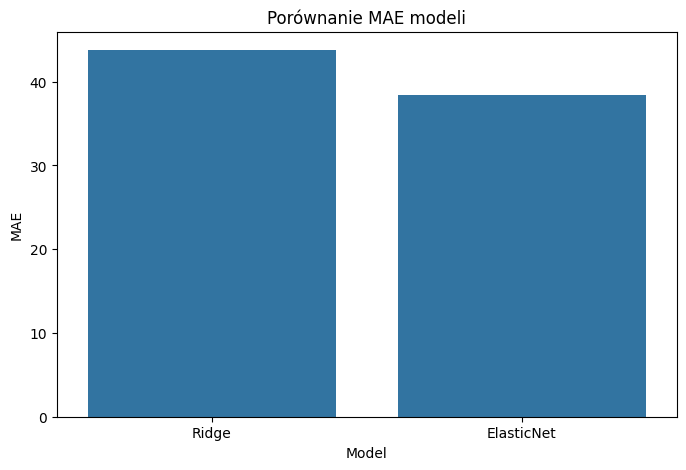

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results = pd.DataFrame({
    "model": ["Ridge", "ElasticNet"],
    "MAE": [43.76986154303357, 38.42697347625917]
})

plt.figure(figsize=(8,5))
sns.barplot(data=results, x="model", y="MAE")
plt.title("Porównanie MAE modeli")
plt.ylabel("MAE")
plt.xlabel("Model")
plt.show()

In [46]:
best_elastic = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(
        alpha=4.3981810937396855,
        l1_ratio=0.997928523653379,
        max_iter=10000,
        random_state=42
    ))
])



cv = LeaveOneGroupOut()

In [47]:
from sklearn.model_selection import cross_val_predict
y_pred_elastic = cross_val_predict(best_elastic, X, y, cv = cv.split(X,y,groups))

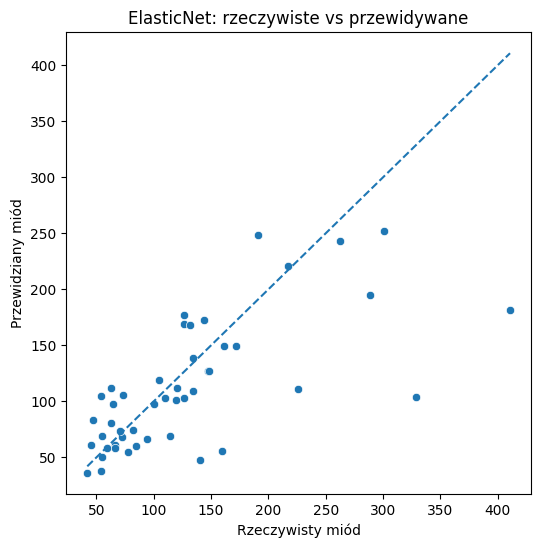

In [48]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y, y=y_pred_elastic)
plt.plot([y.min(), y.max()], [y.min(), y.max()], linestyle="--")
plt.xlabel("Rzeczywisty miód")
plt.ylabel("Przewidziany miód")
plt.title("ElasticNet: rzeczywiste vs przewidywane")
plt.show()

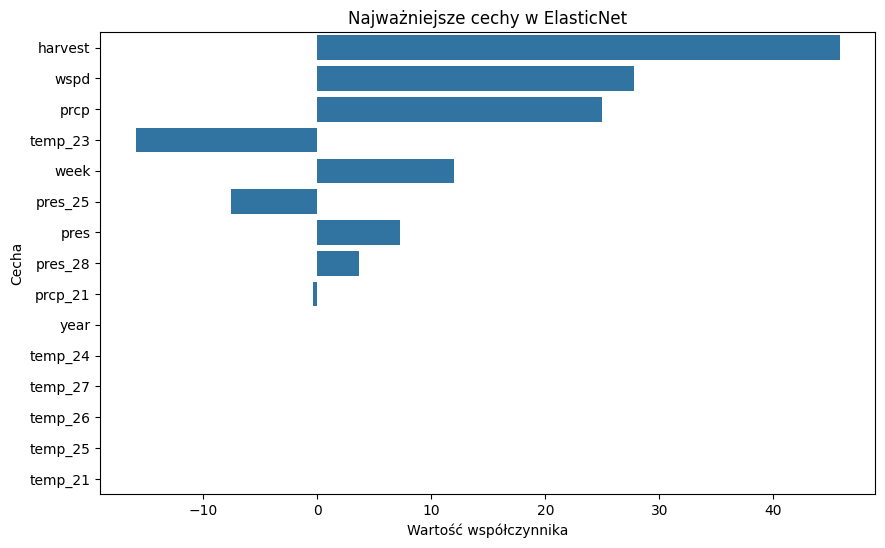

In [49]:
best_elastic.fit(X, y)

coefs = pd.DataFrame({
    "feature": X.columns,
    "coef": best_elastic.named_steps["model"].coef_
})

coefs["abs_coef"] = coefs["coef"].abs()
coefs = coefs.sort_values("abs_coef", ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(data=coefs, x="coef", y="feature")
plt.title("Najważniejsze cechy w ElasticNet")
plt.xlabel("Wartość współczynnika")
plt.ylabel("Cecha")
plt.show()

In [53]:
import shap

best_elastic.fit(X, y)
scaler = best_elastic.named_steps["scaler"]
model = best_elastic.named_steps["model"]

X_scaled = scaler.transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

In [54]:
explainer = shap.LinearExplainer(model, X_scaled_df)
shap_values = explainer(X_scaled_df)

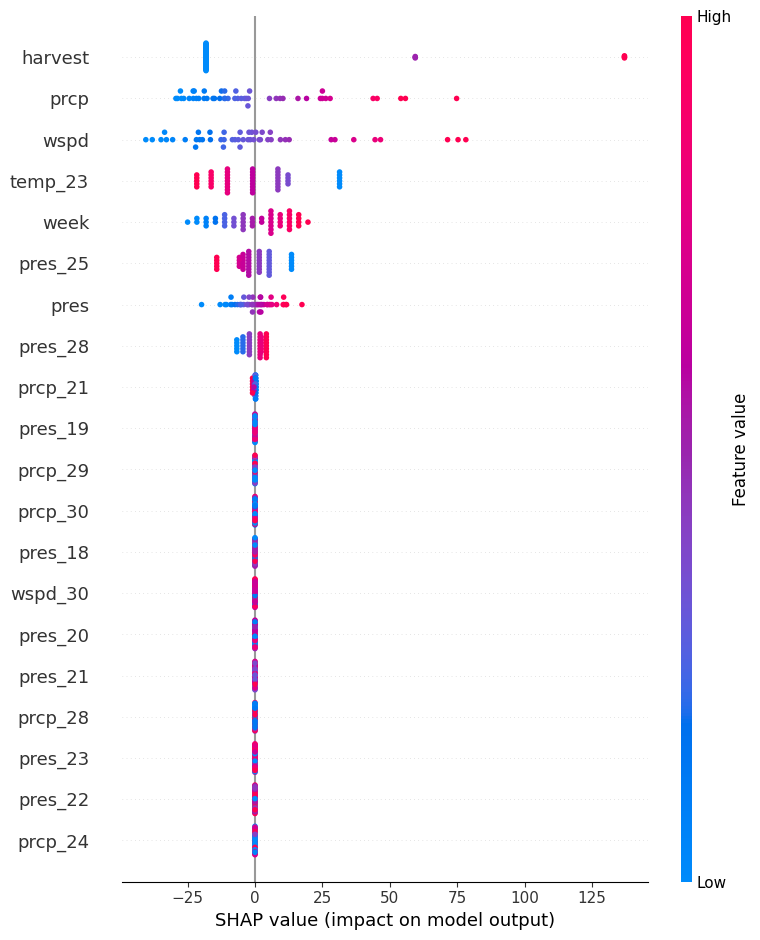

In [55]:
shap.summary_plot(shap_values, X_scaled_df)

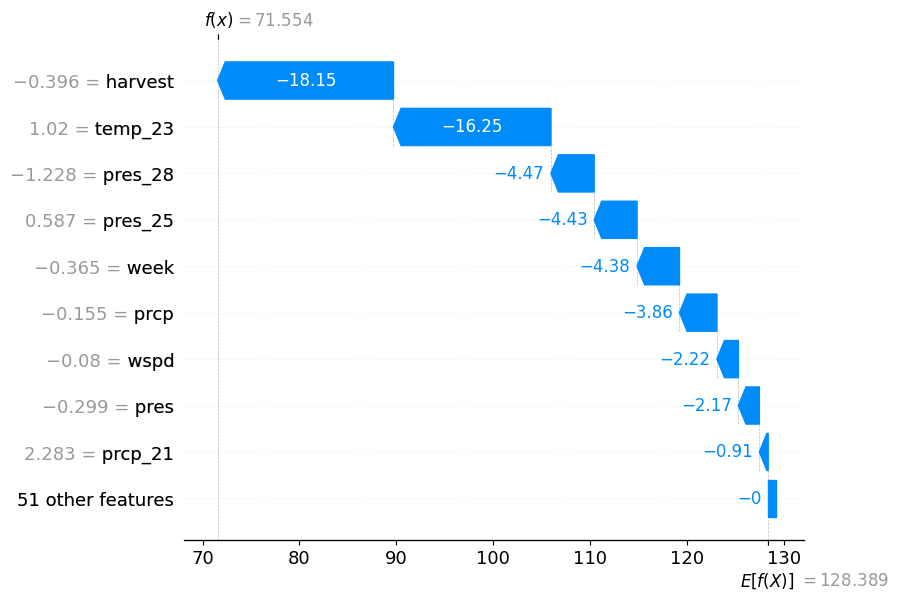

In [56]:
shap.plots.waterfall(shap_values[0])

In [57]:
df_check = X.copy()
df_check["true_honey"] = y
df_check["predicted_honey"] = best_elastic.predict(X)

df_check[["year", "week", "harvest", "true_honey", "predicted_honey"]].head(15)

,year,week,harvest,true_honey,predicted_honey
0,2019,30,1,66.0,71.554318
1,2019,32,1,55.0,79.525592
2,2019,33,2,134.0,147.956509
3,2019,34,1,72.0,75.425915
4,2019,35,1,59.0,66.818551
5,2019,36,1,147.0,134.933165
6,2020,26,2,410.9,321.973258
7,2020,29,1,63.0,148.630715
8,2020,30,1,140.0,109.551487
9,2020,31,1,84.7,144.447108
